In [9]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import numpy as np
import torch
import os
import networkx as nx
from matplotlib.ticker import MultipleLocator


In [10]:
plt.style.use('seaborn-paper')  # 更改图表风格
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 打印默认颜色数组
print(default_colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [11]:
mean_acc_2

NameError: name 'mean_acc_2' is not defined

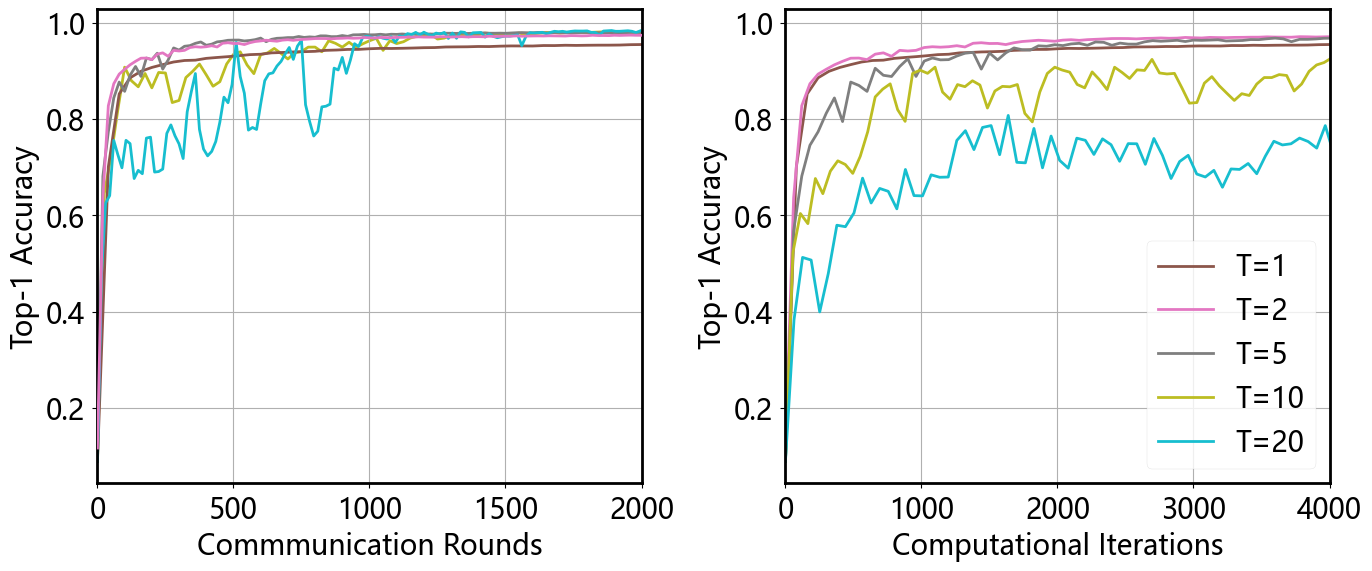

In [12]:
result2_dir="../results/2024-07-24_14-00_dist_mnist_PAPER"
result2_dir="../results/2024-09-06_17-02_dist_mnist_quant_sonata_iter"

# result_dir="../results_paper/2024-09-04_19-29_dist_mnist_iter" #lr=0.005
# result_dir="../results_paper/2024-09-05_20-35_dist_mnist_iter_refine" # lr=0.001
# result_dir="../results_paper/2024-09-09_21-21_dist_mnist_iter_compare" 
result_dir="../results_paper/2024-09-10_13-54_dist_mnist_iter_compare" # lr adjust
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, axs= plt.subplots(1, 2, figsize=(14, 6),tight_layout=True)
ax=axs[1]
iter_1=torch.load(os.path.join(result_dir, "sonata_iter1_results.pt"), map_location=torch.device("cpu"))
iter_2=torch.load(os.path.join(result2_dir, "sonata_results.pt"), map_location=torch.device("cpu"))
iter_5=torch.load(os.path.join(result_dir, "sonata_iter5_results.pt"), map_location=torch.device("cpu"))
iter_10=torch.load(os.path.join(result_dir, "sonata_iter10_results.pt"), map_location=torch.device("cpu"))
iter_20=torch.load(os.path.join(result_dir, "sonata_iter20_results.pt"), map_location=torch.device("cpu"))
comp_times_1=(np.array(iter_1["forward_pass_count"])-64)/64
mean_acc_1=torch.mean(torch.stack(iter_1["top1_accuracy"]), dim=1)
comp_times_2=(np.array(iter_2["forward_pass_count"])-64)/64
mean_acc_2=torch.mean(torch.stack(iter_2["top1_accuracy"]), dim=1)
comp_times_5=(np.array(iter_5["forward_pass_count"])-64)/64
mean_acc_5=torch.mean(torch.stack(iter_5["top1_accuracy"]), dim=1)
comp_times_10=(np.array(iter_10["forward_pass_count"])-64)/64
mean_acc_10=torch.mean(torch.stack(iter_10["top1_accuracy"]), dim=1)
comp_times_20=(np.array(iter_20["forward_pass_count"])-64)/64
mean_acc_20=torch.mean(torch.stack(iter_20["top1_accuracy"]), dim=1)
step=1
ax.plot(comp_times_1[::step], mean_acc_1[::step], label="T=1",color=default_colors[5],linewidth=2)
ax.plot(comp_times_2[::step], mean_acc_2[::step], label="T=2",color=default_colors[6],linewidth=2)
ax.plot(comp_times_5[::step], mean_acc_5[::step], label="T=5",color=default_colors[7],linewidth=2)
ax.plot(comp_times_10[::step], mean_acc_10[::step], label="T=10",color=default_colors[8],linewidth=2)
ax.plot(comp_times_20[::step], mean_acc_20[::step], label="T=20",color=default_colors[9],linewidth=2)
ax.set_xlim(0,4000)
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.grid()
ax.set_ylabel("Top-1 Accuracy",fontsize=20)
ax.set_xlabel("Computational Iterations",fontsize=20)
ax.legend(loc="lower right",fontsize=20)
ax2=axs[0]
t10=np.arange(mean_acc_10.shape[0]) * 5
t20=np.arange(mean_acc_20.shape[0]) * 3
t5=np.arange(mean_acc_5.shape[0]) * 10
step=5
step5=2
ax2.plot(np.arange(mean_acc_1.shape[0]) * 40,mean_acc_1,color=default_colors[5],linewidth=2, label="T=1")
ax2.plot(np.arange(mean_acc_2.shape[0]) * 20,mean_acc_2,color=default_colors[6],zorder=3,linewidth=2,label="T=2")
ax2.plot(t5[::step5],mean_acc_5[::step5],color=default_colors[7],linewidth=2,label="T=5")
ax2.plot(t10[::step],mean_acc_10[::step],color=default_colors[8],zorder=1,linewidth=2,label="T=10")
ax2.plot(t20[::step],mean_acc_20[::step],color=default_colors[9],zorder=2,linewidth=2,label="T=20")
ax2.set_xlabel("Commmunication Rounds",fontsize=20)
ax2.set_ylabel("Top-1 Accuracy",fontsize=20)

# ax.set_ylabel("Top-1准确率",fontsize=20,fontweight='bold')
# ax.set_xlabel("计算迭代次数",fontsize=20,fontweight='bold')
# ax2.set_xlabel("通信轮数",fontsize=20,fontweight='bold')
# ax2.set_ylabel("Top-1准确率",fontsize=20,fontweight='bold')

ax2.xaxis.set_major_locator(MultipleLocator(500))
# 设置x轴刻度标签的字体大小
axs[0].tick_params(axis='x', labelsize=20)
axs[1].tick_params(axis='x', labelsize=20)

# 设置y轴刻度标签的字体大小
axs[0].tick_params(axis='y', labelsize=20)
axs[1].tick_params(axis='y', labelsize=20)
ax2.grid()
ax2.set_xlim(0,2000)
# 对每个子图加边框
for ax_i in axs:
    for spine in ax_i.spines.values():
        spine.set_linewidth(2)  # 设置边框线宽为2
        spine.set_edgecolor('black')  # 设置边框颜色为黑色

In [ ]:
fig.savefig("T_compare.pdf",dpi=800)

In [13]:
print(plt.style.available)
dinno_color="darkorange"
dsgt_color="seagreen"
dsgd_color="slateblue"
sonata_color="crimson"
sonata_color2="c"
randcom_color="blue"
cent_color="indigo"
solo_color="cornflowerblue"

['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


In [5]:
torch.where(t==1000)
len(t)//2

NameError: name 't' is not defined

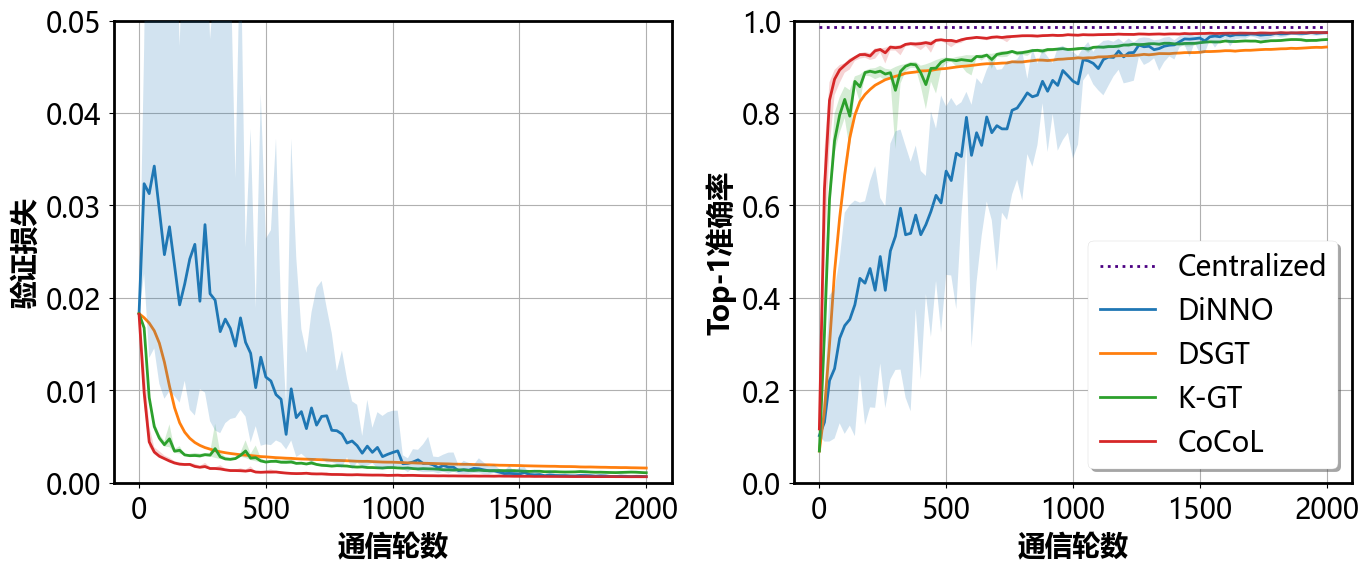

In [14]:
model_param=28440*4/1024/1024*10 #MB
result_dir="../results/2024-07-24_14-00_dist_mnist_PAPER"
dinno_dir="../results/2024-05-22_18-48_dist_mnist_PAPER"
# dinno_dir="../results_paper/2025-02-11_20-32_dist_mnist_paper" # calculate total communication cost
sonata_dir="../results_iros/2025-02-11_21-09_dist_mnist_paper"
# sonata_dir="../results/2024-05-29_16-21_dist_mnist_PAPER"
# randcom_dir="../results/2024-05-23_14-21_MNIST_RANDCOM"
# dsgt_dir="../results/2024-05-29_15-29_dist_mnist_PAPER"
# sonata_cta_dir="../results/2024-05-29_21-53_dist_mnist_PAPER"
cy_dinno = torch.load(os.path.join(dinno_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(result_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_kgt = torch.load(os.path.join(result_dir, "kgt_results.pt"), map_location=torch.device("cpu"))

cy_sonata_atc=torch.load(os.path.join(sonata_dir, "sonata_results.pt"), map_location=torch.device("cpu"))

cy_sonata_atc=iter_2

cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_kgt["top1_accuracy"][:101]) 
cy_acd=torch.stack(cy_sonata_atc["top1_accuracy"])

plt.style.use('seaborn-paper')  # 更改图表风格

fig, ax = plt.subplots(1, 2, figsize=(14, 6),tight_layout=True)
# 对每个子图加边框
for ax_i in ax:
    for spine in ax_i.spines.values():
        spine.set_linewidth(2)  # 设置边框线宽为2
        spine.set_edgecolor('black')  # 设置边框颜色为黑色
t = torch.arange(cy_acb.shape[0]) * 20
# t_dinno=torch.arange(cy_aca.shape[0]) * 20
# data_transfer=t*model_param*2
# data_transfer_dinno=t_dinno*model_param
cent_acc = 0.985
ax[1].plot(t, cent_acc * torch.ones_like(t), c=cent_color,
    linewidth=2, linestyle=":", label="Centralized")

ax[1].plot(t, torch.mean(cy_aca, dim=1), linewidth=2, label="DiNNO")
ax[1].fill_between(t, torch.amax(cy_aca, dim=1), torch.amin(cy_aca, dim=1),
     alpha=0.2, zorder=3)

ax[1].plot(t, torch.mean(cy_acb, dim=1),linewidth=2, label="DSGT")
ax[1].fill_between(t, torch.amax(cy_acb, dim=1), torch.amin(cy_acb, dim=1), alpha=0.2, zorder=1)

ax[1].plot(t, torch.mean(cy_acc, dim=1), linewidth=2, label="K-GT")
ax[1].fill_between(t, torch.amax(cy_acc, dim=1), torch.amin(cy_acc, dim=1), alpha=0.2, zorder=2)

ax[1].plot(t, torch.mean(cy_acd, dim=1),  linewidth=2, label="CoCoL")
ax[1].fill_between(t, torch.amax(cy_acd, dim=1), torch.amin(cy_acd, dim=1),
  alpha=0.2, zorder=4)

ax[1].set_ylim((0.0, 1.0))
# ax[1].set_xlabel("Communication Cost [MB]",fontsize=20)
# ax[1].set_ylabel("Top-1 Accuracy",fontsize=20)
ax[1].set_xlabel("通信轮数",fontsize=20,fontweight='bold')
ax[1].set_ylabel("Top-1准确率",fontsize=20,fontweight='bold')
# fig.suptitle("Ring Graph",fontsize=25)
ax[1].grid(zorder=0)
ax[0].set_ylim((0.0, 0.05))

va_aca=torch.stack(cy_dinno["validation_loss"])
va_acb=torch.stack(cy_dsgt["validation_loss"])
va_acc=torch.stack(cy_kgt["validation_loss"][:101])
va_acd=torch.stack(cy_sonata_atc["validation_loss"])
ax[0].plot(t, torch.mean(va_aca, dim=1), linewidth=2, label="DiNNO")
ax[0].fill_between(t, torch.amax(va_aca, dim=1), torch.amin(va_aca, dim=1),
     alpha=0.2, zorder=3)
ax[0].plot(t, torch.mean(va_acb, dim=1), linewidth=2, label="DSGT")
ax[0].fill_between(t, torch.amax(va_acb, dim=1), torch.amin(va_acb, dim=1), alpha=0.2, zorder=1)
ax[0].plot(t, torch.mean(va_acc, dim=1), linewidth=2, label="K-GT")
ax[0].fill_between(t, torch.amax(va_acc, dim=1), torch.amin(va_acc, dim=1), alpha=0.2, zorder=2)
ax[0].plot(t, torch.mean(va_acd, dim=1), linewidth=2, label="CoCoL")
ax[0].fill_between(t, torch.amax(va_acd, dim=1), torch.amin(va_acd, dim=1),
  alpha=0.2, zorder=4)
ax[1].legend(fontsize=20,shadow=True,frameon=True)
# ax[0].set_xlabel("Communication Cost [MB]",fontsize=20)
# ax[0].set_ylabel("Validation Loss",fontsize=20)
ax[0].set_xlabel("通信轮数",fontsize=20,fontweight='bold')
ax[0].set_ylabel("验证损失",fontsize=20,fontweight='bold')
ax[0].grid(zorder=0)
# 设置x轴的刻度间隔为500
# ax[0].xaxis.set_major_locator(MultipleLocator(500))
# ax[1].xaxis.set_major_locator(MultipleLocator(500))
ax[1].yaxis.set_major_locator(MultipleLocator(0.2))
# 设置x轴刻度标签的字体大小
ax[0].tick_params(axis='x', labelsize=20)
ax[1].tick_params(axis='x', labelsize=20)

# 设置y轴刻度标签的字体大小
ax[0].tick_params(axis='y', labelsize=20)
ax[1].tick_params(axis='y', labelsize=20)
# fig.savefig("ring_graph.png", dpi=1000)
# fig.savefig("ring_graph.pdf", dpi=800)
# ax[1].set_xlim(-5,2220)
# ax[0].set_xlim(-5,2220)



(0.0001, 1.0)

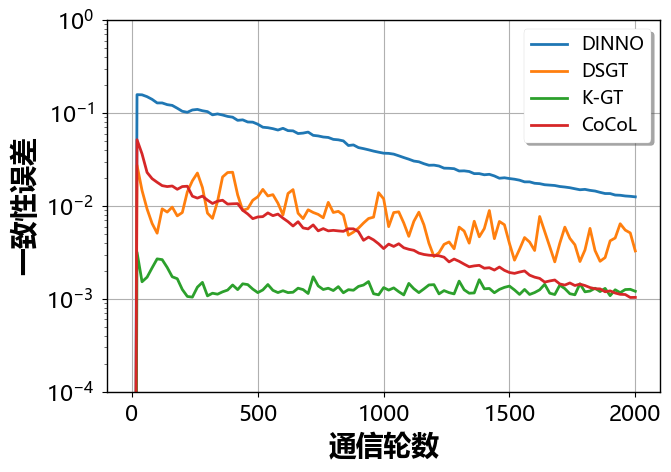

In [15]:
fig,ax=plt.subplots(1,1,figsize=(7,5),tight_layout=True)
agree_cocol=torch.vstack([v[1].reshape(1, -1) for v in cy_sonata_atc["consensus_error"]])
agree_dsgt=torch.vstack([v[1].reshape(1, -1) for v in cy_dsgt["consensus_error"]])
agree_dinno=torch.vstack([v[1].reshape(1, -1) for v in cy_dinno["consensus_error"]])
agree_kgt=torch.vstack([v[1].reshape(1, -1) for v in cy_kgt["consensus_error"]])
ax.plot(t, torch.mean(agree_dinno, dim=1), linewidth=2, label="DINNO")

ax.plot(t, torch.mean(agree_kgt, dim=1), linewidth=2, label="DSGT")
ax.plot(t, torch.mean(agree_dsgt, dim=1), linewidth=2, label="K-GT")

ax.plot(t, torch.mean(agree_cocol, dim=1), linewidth=2, label="CoCoL")
ax.legend(fontsize=13,shadow=True,frameon=True)
ax.set_yscale('log')
# ax.set_ylabel('Consensus Error', fontsize=16)
# ax.set_xlabel('Communication Rounds', fontsize=16)
ax.set_ylabel('一致性误差', fontsize=20,fontweight='bold')
ax.set_xlabel('通信轮数', fontsize=20,fontweight='bold')
ax.xaxis.get_offset_text().set_fontsize(16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(zorder=0)
for spine in ax.spines.values():
    spine.set_linewidth(1)  # 你可以根据需要调整这个值
ax.set_ylim([1e-4,1e0])
# ax.fill_between(t, torch.amax(agree_dsgt, dim=1), torch


In [1]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
co_dir = "../results/2021-09-07_21-01_dist_mnist_complete"
cy_dir = "../results/2021-09-05_14-27_dist_mnist_v3"
r3_dir = "../results/2021-09-07_20-11_dist_mnist_random3"
r8_dir = "../results/2021-09-07_19-01_dist_mnist_random8"
solo_dir  = "../results/2021-09-04_16-01_dist_mnist_v3"

co_dinno = torch.load(os.path.join(co_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
co_dsgt = torch.load(os.path.join(co_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
co_dsgd = torch.load(os.path.join(co_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

cy_dinno = torch.load(os.path.join(cy_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(cy_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_dsgd = torch.load(os.path.join(cy_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

r3_dinno = torch.load(os.path.join(r3_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
r3_dsgt = torch.load(os.path.join(r3_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
r3_dsgd = torch.load(os.path.join(r3_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

r8_dinno = torch.load(os.path.join(r8_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
r8_dsgt = torch.load(os.path.join(r8_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
r8_dsgd = torch.load(os.path.join(r8_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

results_solo = torch.load(os.path.join(solo_dir, "solo_results.pt"), map_location=torch.device("cpu"))

In [3]:
co_G = nx.read_gpickle(os.path.join(co_dir, "graph.gpickle"))
co_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(co_G)
cy_G = nx.read_gpickle(os.path.join(cy_dir, "graph.gpickle"))
cy_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(cy_G)
r3_G = nx.read_gpickle(os.path.join(r3_dir, "graph.gpickle"))
r3_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(r3_G)
r8_G = nx.read_gpickle(os.path.join(r8_dir, "graph.gpickle"))
r8_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(r8_G)

In [2]:
def plot_vals(ax, aca, acb, acc, results_solo, title):
    t = torch.arange(aca.shape[0]) * 20
    cent_acc = 0.985
    ax.plot(t, cent_acc * torch.ones_like(t), c=cent_color,
        linewidth=2, linestyle=":", label="Centralized")
    
    for i in range(9):
        ax.plot(t, results_solo[i]["validation_accuracy"] * np.ones_like(t),
            linewidth=2, color=solo_color, linestyle=":")
    ax.plot(t, results_solo[9]["validation_accuracy"] * np.ones_like(t),
        linewidth=2, color=solo_color, label="Individual", linestyle=":")
    
    ax.plot(t, torch.mean(aca, dim=1), c=dinno_color, linewidth=2, label="DiNNO")
    ax.fill_between(t, torch.amax(aca, dim=1), torch.amin(aca, dim=1),
        color=dinno_color, alpha=0.5, zorder=3)
    
    ax.plot(t, torch.mean(acb, dim=1), c=dsgt_color, linewidth=2, label="DSGT")
    ax.fill_between(t, torch.amax(acb, dim=1), torch.amin(acb, dim=1),
        color=dsgt_color, alpha=0.5, zorder=2)
    
    ax.plot(t, torch.mean(acc, dim=1), c=dsgd_color, linewidth=2, label="DSGD")
    ax.fill_between(t, torch.amax(acc, dim=1), torch.amin(acc, dim=1),
        color=dsgd_color, alpha=0.5, zorder=1)
    
    ax.set_ylim((0.0, 1.0))
    ax.set_title(title)
    ax.set_xlabel("Communication Round")
    ax.grid(zorder=0)

    

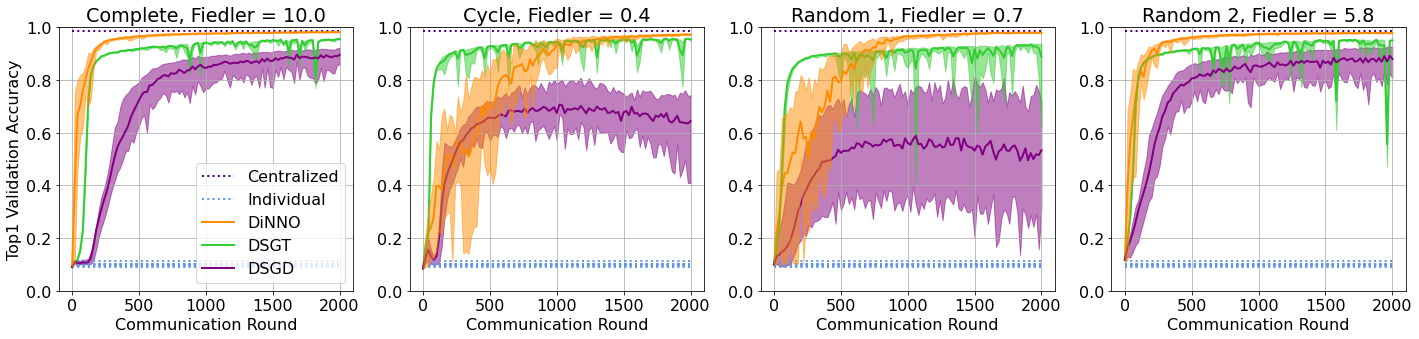

In [5]:
dinno_color="darkorange"
dsgt_color="limegreen"
dsgd_color="purple"
cent_color="indigo"
solo_color="cornflowerblue"

(fig, axs) = plt.subplots(ncols=4, figsize=(20, 5), tight_layout=True)

co_aca = torch.stack(co_dinno["top1_accuracy"]) 
co_acb = torch.stack(co_dsgt["top1_accuracy"]) 
co_acc = torch.stack(co_dsgd["top1_accuracy"]) 

cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_dsgd["top1_accuracy"]) 

r3_aca = torch.stack(r3_dinno["top1_accuracy"]) 
r3_acb = torch.stack(r3_dsgt["top1_accuracy"]) 
r3_acc = torch.stack(r3_dsgd["top1_accuracy"]) 

r8_aca = torch.stack(r8_dinno["top1_accuracy"]) 
r8_acb = torch.stack(r8_dsgt["top1_accuracy"]) 
r8_acc = torch.stack(r8_dsgd["top1_accuracy"]) 

title = "Complete, Fiedler = {:.1f}".format(co_fied)
plot_vals(axs[0], co_aca, co_acb, co_acc, results_solo, title)
axs[0].set_ylabel("Top1 Validation Accuracy")
axs[0].legend(loc=4)

title = "Cycle, Fiedler = {:.1f}".format(cy_fied)
plot_vals(axs[1], cy_aca, cy_acb, cy_acc, results_solo, title)

title = "Random 1, Fiedler = {:.1f}".format(r3_fied)
plot_vals(axs[2], r3_aca, r3_acb, r3_acc, results_solo, title)

title = "Random 2, Fiedler = {:.1f}".format(r8_fied)
plot_vals(axs[3], r8_aca, r8_acb, r8_acc, results_solo, title)

fig.savefig("mnist_four.png", dpi=1000)

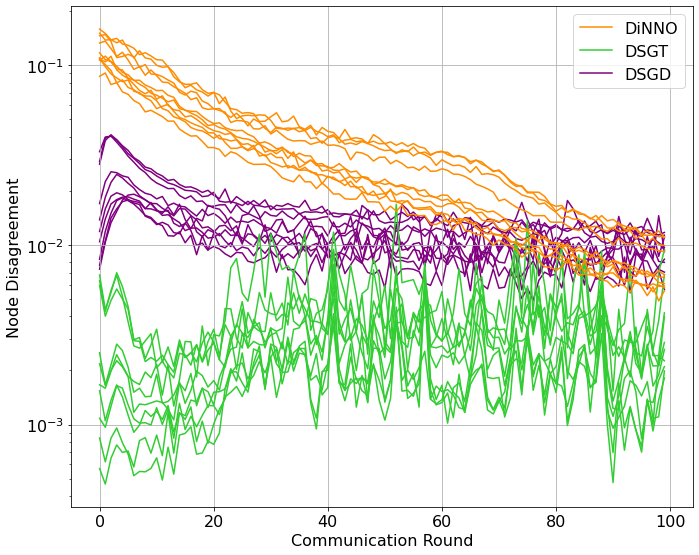

In [6]:
ag_dinno = torch.vstack([v[1].reshape(1, -1) for v in r3_dinno["consensus_error"]])
ag_dsgt = torch.vstack([v[1].reshape(1, -1) for v in r3_dsgt["consensus_error"]])
ag_dsgd = torch.vstack([v[1].reshape(1, -1) for v in r3_dsgd["consensus_error"]])


(fig, ax) = plt.subplots(figsize=(10, 8), tight_layout=True)
ax.plot(ag_dinno[1:, :9], c=dinno_color, zorder=3)
ax.plot(ag_dinno[1:, 9], c=dinno_color, label="DiNNO", zorder=3)

ax.plot(ag_dsgt[1:, :9], c=dsgt_color, zorder=2)
ax.plot(ag_dsgt[1:, 9], c=dsgt_color, label="DSGT", zorder=2)

ax.plot(ag_dsgd[1:, :9], c=dsgd_color, zorder=1)
ax.plot(ag_dsgd[1:, 9], c=dsgd_color, label="DSGD", zorder=1)

ax.set_yscale("log")
ax.grid()
ax.set_xlabel("Communication Round")
ax.set_ylabel("Node Disagreement")
ax.legend(loc=1)
fig.savefig("mnist_agree.svg")

In [33]:
result_dir="../results/2024-07-29_17-16_dist_mnist_Quant_16"
dinno_dir="../results/2024-07-29_17-16_dist_mnist_Quant_16"
sonata_dir="../results/2024-07-29_17-45_dist_mnist_quant_sonata_16"
# randcom_dir="../results/2024-05-23_14-21_MNIST_RANDCOM"
dsgt_dir="../results/2024-07-29_18-09_dist_mnist_dsgt_Quant"
# sonata_cta_dir="../results/2024-05-29_21-53_dist_mnist_PAPER"
cy_dinno = torch.load(os.path.join(result_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(dsgt_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_kgt = torch.load(os.path.join(result_dir, "kgt_results.pt"), map_location=torch.device("cpu"))
cy_sonata_atc=torch.load(os.path.join(sonata_dir, "sonata_results.pt"), map_location=torch.device("cpu"))


cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_kgt["top1_accuracy"]) 
cy_acd=torch.stack(cy_sonata_atc["top1_accuracy"])
mean_aca=torch.mean(cy_aca,dim=1)
mean_acb=torch.mean(cy_acb,dim=1)
mean_acc=torch.mean(cy_acc,dim=1)
mean_acd=torch.mean(cy_acd,dim=1)
t = torch.arange(mean_aca.shape[0]) * 20
print(t[np.argmax(mean_aca>0.95)],t[np.argmax(mean_acb>0.939)],t[np.argmax(mean_acc>0.95)],t[np.argmax(mean_acd>0.95)])


tensor(620) tensor(1940) tensor(800) tensor(320)


In [198]:
result_dir_10="../results_scaling/2025-02-17_14-38_scaling_dinno_const_fied_10"
result_dir_20="../results_scaling/2025-02-13_21-54_scaling_dinno_const_fied_20"
num_trial=5
sequence=101

def print_metric(result_dir,acc=0.95,num_trial=5):
    
    sonata_list=np.zeros((num_trial,sequence))
    dinno_list=np.zeros((num_trial,sequence))
    dsgt_list=np.zeros((num_trial,sequence))
    kgt_list=np.zeros((num_trial,sequence))
    for i in range(num_trial):
        sonata_result=torch.load(os.path.join(result_dir, "sonata_{}_results.pt".format(i)), map_location=torch.device("cpu"))
        mean_sonata=torch.mean(torch.stack(sonata_result["top1_accuracy"]), dim=1)
        dinno_result=torch.load(os.path.join(result_dir, "dinno_{}_results.pt".format(i)), map_location=torch.device("cpu"))
        mean_dinno=torch.mean(torch.stack(dinno_result["top1_accuracy"]), dim=1)
        dsgt_result=torch.load(os.path.join(result_dir, "dsgt_{}_results.pt".format(i)), map_location=torch.device("cpu"))
        mean_dsgt=torch.mean(torch.stack(dsgt_result["top1_accuracy"]), dim=1)
        kgt_result=torch.load(os.path.join(result_dir, "kgt_{}_results.pt".format(i)), map_location=torch.device("cpu"))
        mean_kgt=torch.mean(torch.stack(kgt_result["top1_accuracy"]), dim=1)
        
        sonata_list[i]=mean_sonata.numpy()
        dinno_list[i]=mean_dinno.numpy()
        dsgt_list[i]=mean_dsgt.numpy()
        kgt_list[i]=mean_kgt.numpy()
    t=torch.arange(sonata_list[0].shape[0])*20
    
    dinno_res=np.argmax(dinno_list>acc,axis=1)*20
    sonata_res=np.argmax(sonata_list>acc,axis=1)*20
    kgt_res=np.argmax(kgt_list>acc,axis=1)*20
    dsgt_res=np.argmax(dsgt_list>0.92,axis=1)*20

    print(np.mean(dsgt_res),np.std(dsgt_res))
    print(np.mean(kgt_res),np.std(kgt_res))

    print(np.mean(dinno_res),np.std(dinno_res))
    print(np.mean(sonata_res),np.std(sonata_res))
    print("----------------")
print_metric(result_dir_10,0.945)
# result_dir_20="../results_scaling/2025-02-13_21-54_scaling_dinno_const_fied_20"
result_dir_20="../results_scaling/2025-02-14_15-01_scaling_dinno_const_fied_20"
print_metric(result_dir_20,0.95)
result_dir_50="../results_scaling/2025-02-14_15-12_scaling_dinno_const_fied_50"
print_metric(result_dir_50,0.95)
result_dir_100="../results_scaling/2025-02-14_15-16_scaling_dinno_const_fied_100"
print_metric(result_dir_100,0.95)


1280.0 272.176413379264
592.0 98.46826900072936
380.0 63.245553203367585
184.0 19.595917942265423
----------------
1292.0 268.50698314941457
688.0 111.42710621747295
380.0 85.79044235810886
128.0 20.396078054371138
----------------
1296.0 269.6367927416435
700.0 119.33147112141039
460.0 97.97958971132712
160.0 17.88854381999832
----------------
1292.0 272.6462910072316
688.0 111.42710621747295
444.0 86.16263691415206
104.0 14.966629547095765
----------------


In [156]:
result_dir_50="../results_scaling/2025-02-13_21-54_scaling_dinno_const_fied_50"
print_metric(result_dir_50,0.95,num_trial=4)

1365.0 247.53787588973125
730.0 95.39392014169457
450.0 70.0
260.0 67.82329983125268


In [160]:
result_dir_100="../results_scaling/2025-02-13_21-55_scaling_dinno_const_fied_100"
print_metric(result_dir_100,0.94,num_trial=2)

1510.0 250.0
550.0 70.0
380.0 80.0
200.0 20.0
